# RBF Fake-Lab Active Learning Sandbox

This notebook is for testing the active-learning idea without touching the model-generation pipeline.

The RBF is used as a fast synthetic experiment:

1. Fit a smooth RBF surface to the full FLIPMM dataset.
2. Query that RBF as if it were an experiment.
3. Optionally add controlled Gaussian measurement noise.
4. Compare next-point selection strategies using the same equation pool.

The important question is not whether the RBF is the final model. It is whether the sampling strategy helps the equation-based learner improve with fewer observations.

In [32]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

from active_learning_uncertainty import (
    SUMMARY_PATH,
    acquisition_scores,
    fit_rbf_truth,
    load_equations_from_file,
    load_equations_from_summary,
    observe_truth,
    simulate_trace,
)
from src.config_loader import load_config, resolve_path

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

ROOT = Path.cwd()
OUT_DIR = ROOT / "output" / "active_learning_uncertainty" / "notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Writing notebook outputs to: {OUT_DIR}")

Writing notebook outputs to: c:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\active_learning_uncertainty\notebook


## Experiment Settings

Adjust these values first. `NOISE_STD` controls how noisy the synthetic experiment observations are. Validation still compares predictions against the clean RBF surface, so the question becomes: can the method recover the underlying trend from noisy measurements?

In [33]:
NOISE_STD = 0
RANDOM_STATE = 50
SEED_SIZE = 1
ADD_STEPS = 12
BENCHMARK_SEEDS = 10
TOP_MODELS = 5
N_CANDIDATES = 3000
N_VALIDATION = 2000

STRATEGIES = [
    "random",
    "space_filling",
    "rbf_uncertainty",
    "bayesian_optimization",
    "greatest_disagreement_range",
    "greatest_disagreement_std",
]

# Set this to "output/one_shot_literature_equations.py" if you want to use
# the literature-only equation file instead of output/run_summary.txt.
EQUATION_FILE = None

## Load FLIPMM and Fit the RBF Fake Lab

In [34]:
cfg = load_config()
input_cols = cfg["input_columns"]
output_col = cfg["output_column"]

df = pd.read_excel(resolve_path(cfg, cfg["dataset"]["file"]))
truth = fit_rbf_truth(df, input_cols, output_col)

print(f"Rows: {len(df)}")
print(f"Inputs: {input_cols}")
print(f"Output: {output_col}")
df[input_cols + [output_col]].head()

Rows: 256
Inputs: ['WaterSpeed (m/s)', 'PulseEnergy (microJ)', 'Frequency (kHz)', 'ScanningSpeed (mm/s)']
Output: MRR (cubic micrometer per sec)


,WaterSpeed (m/s),PulseEnergy (microJ),Frequency (kHz),ScanningSpeed (mm/s),MRR (cubic micrometer per sec)
0,6.0,10.0,2.000000,1.000000,-21.350338
1,6.0,10.0,2.000000,3.666667,-15.331817
2,6.0,10.0,2.000000,6.333333,-14.376265
3,6.0,10.0,2.000000,9.000000,-18.483682
4,6.0,10.0,7.333333,1.000000,-2.643142


## Sanity Check: RBF Fit at Original Data Points

This checks whether the fake lab reproduces the data used to build it. With noise enabled, the scatter shows the noisy measurements a learner would see.

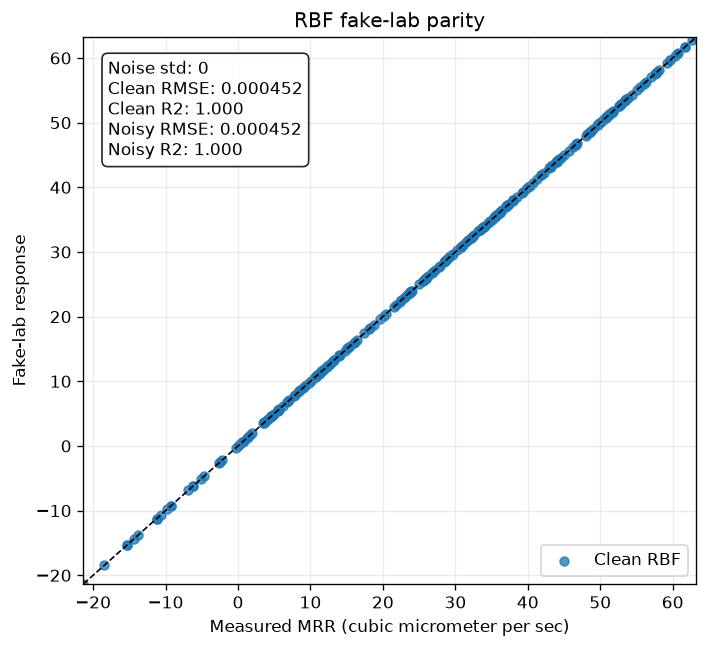

In [35]:
rng = np.random.default_rng(RANDOM_STATE)
X = df[input_cols].to_numpy(dtype=float)
y_measured = df[output_col].to_numpy(dtype=float)
y_clean = truth(X)
y_observed = observe_truth(truth, X, rng, NOISE_STD)

rmse_clean = mean_squared_error(y_measured, y_clean) ** 0.5
r2_clean = r2_score(y_measured, y_clean)
rmse_noisy = mean_squared_error(y_measured, y_observed) ** 0.5
r2_noisy = r2_score(y_measured, y_observed)

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.scatter(y_measured, y_clean, s=28, alpha=0.75, label="Clean RBF")
if NOISE_STD > 0:
    ax.scatter(y_measured, y_observed, s=18, alpha=0.5, label="Noisy observations")
limits = [min(y_measured.min(), y_observed.min(), y_clean.min()), max(y_measured.max(), y_observed.max(), y_clean.max())]
ax.plot(limits, limits, color="black", linestyle="--", linewidth=1)
ax.set_xlim(limits)
ax.set_ylim(limits)
ax.set_xlabel(f"Measured {output_col}")
ax.set_ylabel("Fake-lab response")
ax.set_title("RBF fake-lab parity")
ax.legend()
ax.text(
    0.04,
    0.96,
    f"Noise std: {NOISE_STD}\nClean RMSE: {rmse_clean:.3g}\nClean R2: {r2_clean:.3f}\nNoisy RMSE: {rmse_noisy:.3g}\nNoisy R2: {r2_noisy:.3f}",
    transform=ax.transAxes,
    va="top",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "alpha": 0.85},
)
fig.tight_layout()
fig.savefig(OUT_DIR / "rbf_fake_lab_parity.png", dpi=180)

## Load the Equation Pool

The notebook reuses the same equation loading code as the scripts. By default this uses equations from `output/run_summary.txt`. You can switch to the one-shot literature equations by setting `EQUATION_FILE` above.

In [36]:
if EQUATION_FILE:
    equation_path = resolve_path(cfg, EQUATION_FILE)
    equations = load_equations_from_file(equation_path, TOP_MODELS)
else:
    equation_path = SUMMARY_PATH
    equations = load_equations_from_summary(SUMMARY_PATH, TOP_MODELS)

print(f"Loaded {len(equations)} equation forms from {equation_path}")
[name for _, _, name in equations]

Loaded 3 equation forms from C:\Users\Duncan\Desktop\UConn\CEaD\Knowledge-to-analytical-model-manufacturing-process\output\run_summary.txt


['summary_model_1', 'summary_model_2', 'summary_model_3']

## Run the Strategy Benchmark

Each strategy starts from the same seed sizes and queries the RBF fake lab. Observed points receive `NOISE_STD` measurement noise. Validation points stay clean so we can evaluate recovery of the underlying response surface.

In [37]:
traces = []
for seed_offset in range(BENCHMARK_SEEDS):
    seed = RANDOM_STATE + seed_offset
    for strategy in STRATEGIES:
        traces.append(
            simulate_trace(
                cfg=cfg,
                df=df,
                truth=truth,
                equations=equations,
                strategy=strategy,
                seed_size=SEED_SIZE,
                add_steps=ADD_STEPS,
                n_candidates=N_CANDIDATES,
                n_validation=N_VALIDATION,
                random_state=seed,
                noise_std=NOISE_STD,
            )
        )

all_traces = pd.concat(traces, ignore_index=True)
summary = (
    all_traces.groupby(["strategy", "step", "n_observed"], as_index=False)
    .agg(
        r2_mean=("r2_on_rbf_truth", "mean"),
        r2_std=("r2_on_rbf_truth", "std"),
        rmse_mean=("rmse_on_rbf_truth", "mean"),
        rmse_std=("rmse_on_rbf_truth", "std"),
    )
    .fillna(0.0)
)
final = (
    all_traces[all_traces["step"] == ADD_STEPS]
    .groupby("strategy", as_index=False)
    .agg(
        final_r2_mean=("r2_on_rbf_truth", "mean"),
        final_r2_std=("r2_on_rbf_truth", "std"),
        final_rmse_mean=("rmse_on_rbf_truth", "mean"),
        final_rmse_std=("rmse_on_rbf_truth", "std"),
    )
    .sort_values("final_r2_mean", ascending=False)
)

all_traces.to_csv(OUT_DIR / f"benchmark_all_traces_noise_{NOISE_STD:g}.csv", index=False)
summary.to_csv(OUT_DIR / f"benchmark_summary_noise_{NOISE_STD:g}.csv", index=False)
final.to_csv(OUT_DIR / f"benchmark_final_rankings_noise_{NOISE_STD:g}.csv", index=False)

final

,strategy,final_r2_mean,final_r2_std,final_rmse_mean,final_rmse_std
3,random,0.872863,0.046724,5.393716,0.947203
2,greatest_disagreement_std,0.857549,0.030765,5.766277,0.668529
4,rbf_uncertainty,0.848798,0.065060,5.855082,1.273637
1,greatest_disagreement_range,0.844773,0.045793,5.997450,0.900923
5,space_filling,0.693746,0.201800,8.076774,2.763873
0,bayesian_optimization,0.666565,0.153151,8.673232,1.949593


## Plot Learning Curves

Higher R2 means the current equation-plus-residual model is better at predicting clean held-out RBF samples.

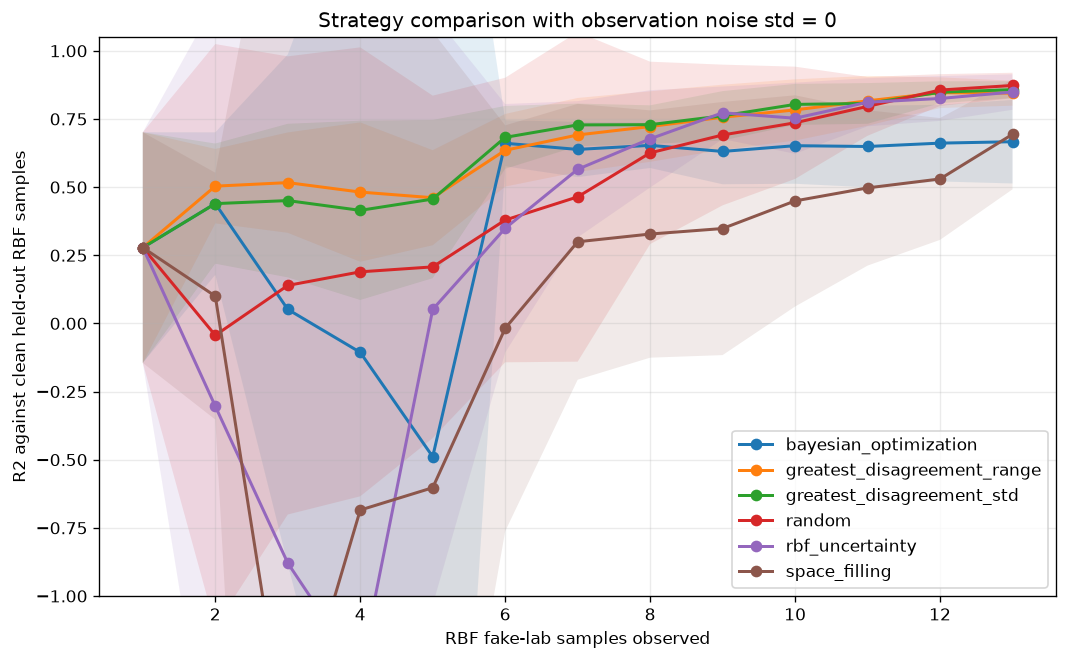

In [38]:
fig, ax = plt.subplots(figsize=(9, 5.6))
for strategy, group in summary.groupby("strategy"):
    group = group.sort_values("n_observed")
    ax.plot(group["n_observed"], group["r2_mean"], marker="o", linewidth=1.8, label=strategy)
    ax.fill_between(
        group["n_observed"],
        group["r2_mean"] - group["r2_std"],
        group["r2_mean"] + group["r2_std"],
        alpha=0.12,
    )

ax.set_xlabel("RBF fake-lab samples observed")
ax.set_ylabel("R2 against clean held-out RBF samples")
ax.set_title(f"Strategy comparison with observation noise std = {NOISE_STD:g}")
ax.set_ylim(-1.0, 1.05)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUT_DIR / f"strategy_comparison_noise_{NOISE_STD:g}.png", dpi=180)

## Optional: Compare Several Noise Levels

This cell is slower because it reruns the benchmark for every listed noise level. It is useful for asking when equation disagreement stops being helpful and residual uncertainty starts mattering more.

In [39]:
RUN_NOISE_SWEEP = False
NOISE_LEVELS = [0.0, 1.0, 2.0, 4.0]

if RUN_NOISE_SWEEP:
    sweep_rows = []
    for noise_std in NOISE_LEVELS:
        traces = []
        for seed_offset in range(BENCHMARK_SEEDS):
            seed = RANDOM_STATE + seed_offset
            for strategy in STRATEGIES:
                traces.append(
                    simulate_trace(
                        cfg=cfg,
                        df=df,
                        truth=truth,
                        equations=equations,
                        strategy=strategy,
                        seed_size=SEED_SIZE,
                        add_steps=ADD_STEPS,
                        n_candidates=N_CANDIDATES,
                        n_validation=N_VALIDATION,
                        random_state=seed,
                        noise_std=noise_std,
                    )
                )
        trace = pd.concat(traces, ignore_index=True)
        final_step = trace[trace["step"] == ADD_STEPS]
        ranked = (
            final_step.groupby("strategy", as_index=False)
            .agg(final_r2_mean=("r2_on_rbf_truth", "mean"), final_r2_std=("r2_on_rbf_truth", "std"))
            .assign(noise_std=noise_std)
        )
        sweep_rows.append(ranked)

    noise_sweep = pd.concat(sweep_rows, ignore_index=True)
    noise_sweep.to_csv(OUT_DIR / "noise_sweep_final_rankings.csv", index=False)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for strategy, group in noise_sweep.groupby("strategy"):
        group = group.sort_values("noise_std")
        ax.plot(group["noise_std"], group["final_r2_mean"], marker="o", label=strategy)
    ax.set_xlabel("Observation noise std")
    ax.set_ylabel("Final R2 against clean RBF truth")
    ax.set_title("Strategy robustness to fake-lab measurement noise")
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "noise_sweep_final_r2.png", dpi=180)

    noise_sweep.sort_values(["noise_std", "final_r2_mean"], ascending=[True, False])
else:
    print("Set RUN_NOISE_SWEEP = True to run the multi-noise comparison.")

Set RUN_NOISE_SWEEP = True to run the multi-noise comparison.


## Interpretation Notes

- `random`: baseline. If a method cannot beat this reliably, it may not be adding useful information.
- `space_filling`: samples far from observed points. Good for coverage, but it ignores equation behavior.
- `rbf_uncertainty`: uses the residual GP uncertainty. This tends to matter more when observations are noisy.
- `bayesian_optimization`: expected improvement. This is useful for finding high-output regions, but may be poor for learning the full response surface.
- `greatest_disagreement_range`: samples where the highest and lowest equation predictions differ most.
- `greatest_disagreement_std`: samples where equation predictions have the largest standard deviation.

For this project, the most interesting result is not necessarily the highest predicted MRR. The useful result is whether literature-derived equation structures can guide sampling toward faster surface learning.

## Averaged R2 and RMSE Learning Curves

This uses the benchmark traces already run above. Each curve is averaged over `BENCHMARK_SEEDS` repeated runs, so the plot shows the expected behavior as each new fake-lab data point is added.

WindowsPath('c:/Users/Duncan/Desktop/UConn/CEaD/Knowledge-to-analytical-model-manufacturing-process/output/active_learning_uncertainty/notebook/averaged_r2_rmse_learning_curves_noise_0.png')

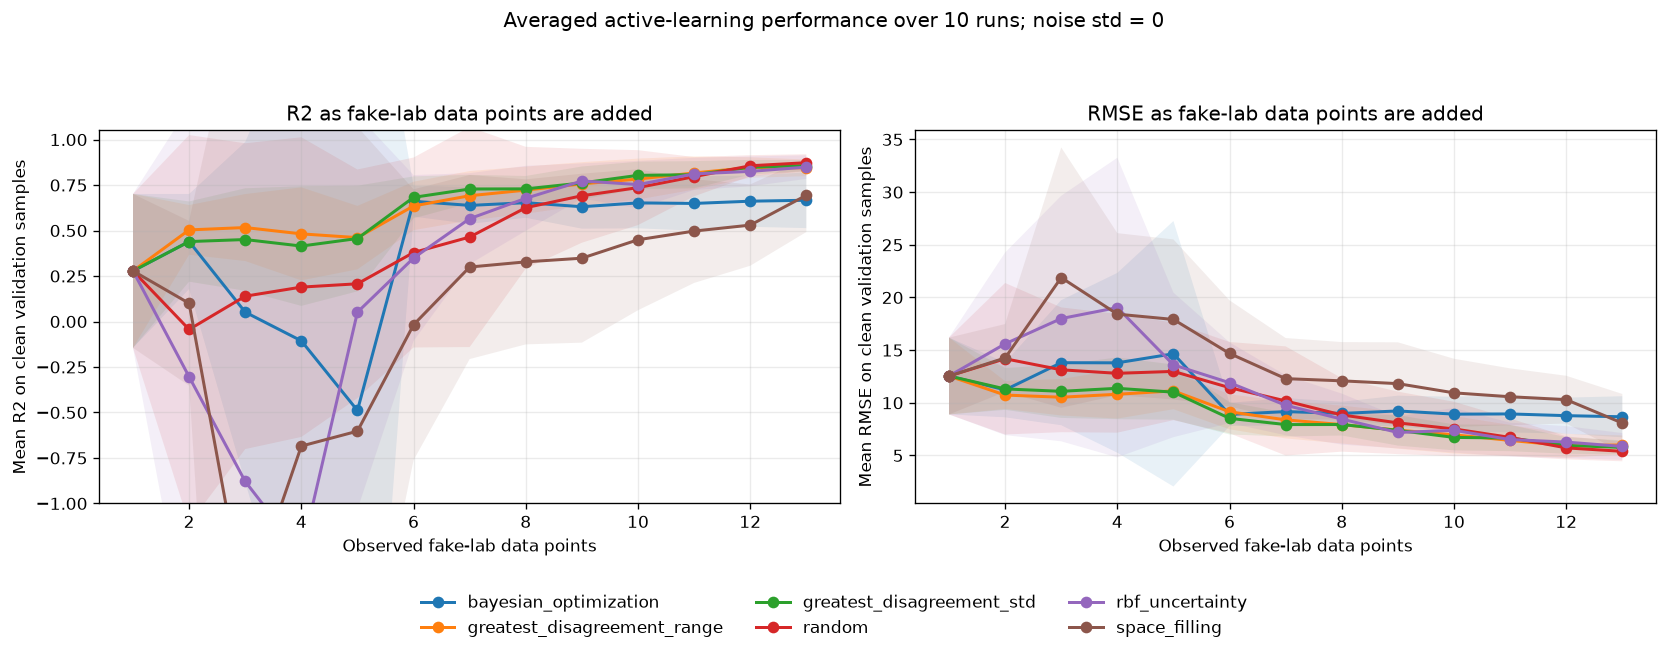

In [40]:
learning_curve_summary = (
    all_traces.groupby(["strategy", "n_observed"], as_index=False)
    .agg(
        r2_mean=("r2_on_rbf_truth", "mean"),
        r2_std=("r2_on_rbf_truth", "std"),
        rmse_mean=("rmse_on_rbf_truth", "mean"),
        rmse_std=("rmse_on_rbf_truth", "std"),
    )
    .fillna(0.0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharex=True)

for strategy, group in learning_curve_summary.groupby("strategy"):
    group = group.sort_values("n_observed")
    axes[0].plot(group["n_observed"], group["r2_mean"], marker="o", linewidth=1.8, label=strategy)
    axes[0].fill_between(
        group["n_observed"],
        group["r2_mean"] - group["r2_std"],
        group["r2_mean"] + group["r2_std"],
        alpha=0.10,
    )
    axes[1].plot(group["n_observed"], group["rmse_mean"], marker="o", linewidth=1.8, label=strategy)
    axes[1].fill_between(
        group["n_observed"],
        group["rmse_mean"] - group["rmse_std"],
        group["rmse_mean"] + group["rmse_std"],
        alpha=0.10,
    )

axes[0].set_title("R2 as fake-lab data points are added")
axes[0].set_xlabel("Observed fake-lab data points")
axes[0].set_ylabel("Mean R2 on clean validation samples")
axes[0].set_ylim(-1.0, 1.05)

axes[1].set_title("RMSE as fake-lab data points are added")
axes[1].set_xlabel("Observed fake-lab data points")
axes[1].set_ylabel("Mean RMSE on clean validation samples")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle(f"Averaged active-learning performance over {BENCHMARK_SEEDS} runs; noise std = {NOISE_STD:g}", y=1.02)
fig.tight_layout(rect=(0, 0.12, 1, 0.96))

averaged_curve_path = OUT_DIR / f"averaged_r2_rmse_learning_curves_noise_{NOISE_STD:g}.png"
learning_curve_summary.to_csv(OUT_DIR / f"averaged_r2_rmse_learning_curves_noise_{NOISE_STD:g}.csv", index=False)
fig.savefig(averaged_curve_path, dpi=180)
averaged_curve_path